<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/XR/TESTS/Lab4_Bragg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab4 XR: Bragg experiment with KBr crystals

Evgeny Kolonsky 2026


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.constants import c, h, electron_volt as eV
import requests
from io import BytesIO
from PIL import Image

URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/XR/TESTS/'

# Resume

It is expected that successful goniometer autocalibration is accompanied by two well-expressed black-line peaks on the X-ray display. The experiment manual states:
> Make sure that by the end of the calibration the graph of the intensity vs the angle (shown on the panel) displays well defined peaks. If not, call the instructor.

This is indeed so for `Cu` and `Fe` lamps with the `KBr` crystal. However, the peaks are not seen for the `Mo` lamp with the `KBr` crystal. Nevertheless, the experiment results look reasonable for all lamps, both with well-defined peaks and without.

Note that Goniometer autocalibration always finishes with `Successful calibration` message, even when done with broken  lamp which does not produce X-rays at all. This message is not informative.

# Mo + KBr

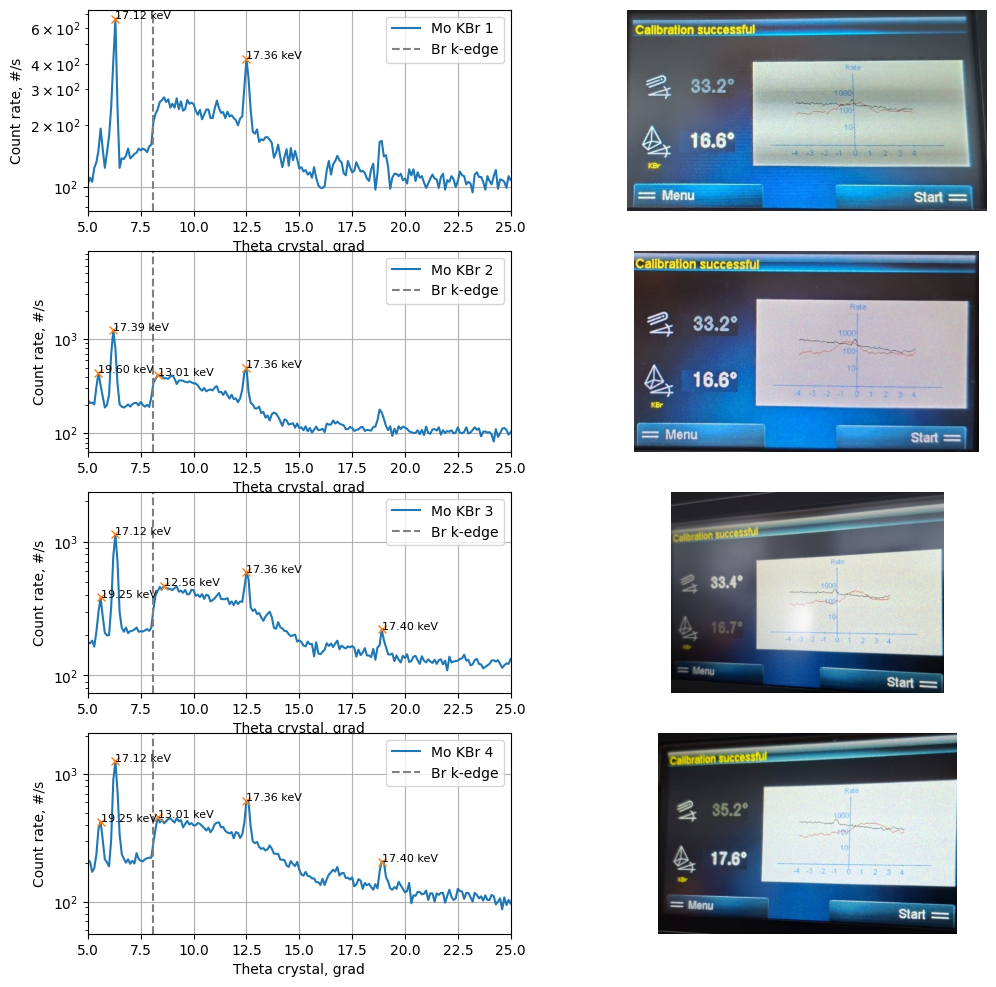

In [27]:
crystal = 'KBr'
d = 330e-12 #m
lamp = 'Mo'

fig, axs = plt.subplots(4, 2, figsize=(12, 12))
for n in  [1,2,3,4]:
  ax = axs[n-1,0]
  filename = URL + f'{lamp}_{crystal}_{n}.txt'
  theta, count = np.genfromtxt(filename, skip_header=3, unpack=True, encoding='latin1')
  theta_rad = theta * np.pi / 180
  peaks, _ = find_peaks(count, prominence=80)
  ax.plot(theta, count,  label=f'{lamp} {crystal} {n}')
  ax.plot(theta[peaks], count[peaks], 'x')

  k_edge = 8.1 # degrees
  l = 2 * d * np.sin(k_edge * np.pi / 180)
  E = h * c / l
  ax.axvline(x=k_edge, color='gray', ls='--', label=f'Br k-edge')

  ax.set_yscale('log')
  ax.set_xlabel('Theta crystal, grad')
  ax.set_ylabel('Count rate, #/s')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(5, 25)
  for peak in peaks:
    if theta[peak] < 9:
      order = 1
    elif theta[peak] < 18:
      order = 2
    else:
      order = 3
    l = 2 * d * np.sin(theta_rad[peak]) / order
    E = h * c / l
    #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
    ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)

  # photo of calibration
  ax = axs[n-1,1]
  filename = URL + f'{lamp}_{crystal}_{n}.jpg'
  response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
  image = Image.open(BytesIO(response.content))
  ax.imshow(image)
  ax.axis("off")  # Hides grid lines and pixel axes



# Ferrum + KBr



(np.float64(-0.5), np.float64(750.5), np.float64(437.5), np.float64(-0.5))

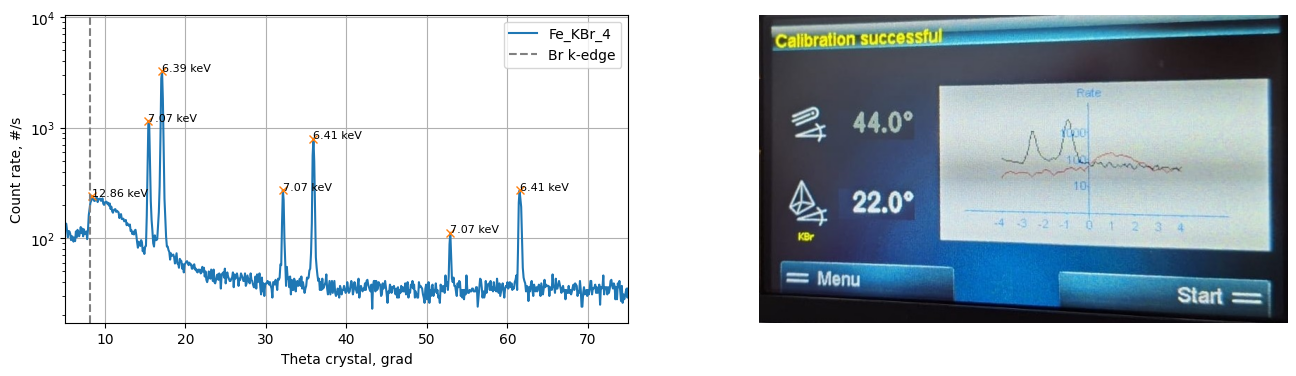

In [33]:
crystal = 'KBr'
d = 330e-12 #m
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
filename = 'Fe_KBr_4'
ax = axs[0]
theta, count = np.genfromtxt(URL+filename+'.txt', skip_header=3, unpack=True, encoding='latin1')
theta_rad = theta * np.pi / 180
peaks, _ = find_peaks(count, prominence=50)
ax.plot(theta, count,  label=f'{filename}')
ax.plot(theta[peaks], count[peaks], 'x')

k_edge = 8.1 # degrees
l = 2 * d * np.sin(k_edge * np.pi / 180)
E = h * c / l
ax.axvline(x=k_edge, color='gray', ls='--', label=f'Br k-edge')

ax.set_yscale('log')
ax.set_xlabel('Theta crystal, grad')
ax.set_ylabel('Count rate, #/s')
ax.grid(True)
ax.legend()
ax.set_xlim(5, 75)
for peak in peaks:
  if theta[peak] < 25:
    order = 1
  elif theta[peak] < 45:
    order = 2
  else:
    order = 3
  l = 2 * d * np.sin(theta_rad[peak]) / order
  E = h * c / l
  #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
  ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)

# photo of calibration
ax = axs[1]
filename = URL + filename +'.jpg'
response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
image = Image.open(BytesIO(response.content))
ax.imshow(image)
ax.axis("off")  # Hides grid lines and pixel axes




# Cuprum + KBr

(np.float64(-0.5), np.float64(725.5), np.float64(437.5), np.float64(-0.5))

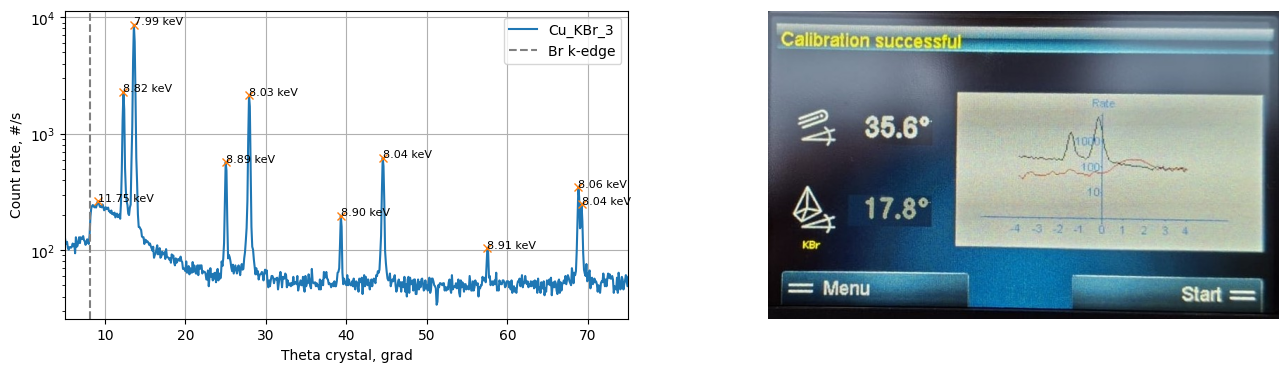

In [35]:
crystal = 'KBr'
d = 330e-12 #m
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
filename = 'Cu_KBr_3'
ax = axs[0]
theta, count = np.genfromtxt(URL+filename+'.txt', skip_header=3, unpack=True, encoding='latin1')
theta_rad = theta * np.pi / 180
peaks, _ = find_peaks(count, prominence=50)
ax.plot(theta, count,  label=f'{filename}')
ax.plot(theta[peaks], count[peaks], 'x')

k_edge = 8.1 # degrees
l = 2 * d * np.sin(k_edge * np.pi / 180)
E = h * c / l
ax.axvline(x=k_edge, color='gray', ls='--', label=f'Br k-edge')

ax.set_yscale('log')
ax.set_xlabel('Theta crystal, grad')
ax.set_ylabel('Count rate, #/s')
ax.grid(True)
ax.legend()
ax.set_xlim(5, 75)
for peak in peaks:
  if theta[peak] < 20:
    order = 1
  elif theta[peak] < 35:
    order = 2
  elif theta[peak] < 50:
    order = 3
  else:
    order = 4
  l = 2 * d * np.sin(theta_rad[peak]) / order
  E = h * c / l
  #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
  ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)

# photo of calibration
ax = axs[1]
filename = URL + filename +'.jpg'
response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
image = Image.open(BytesIO(response.content))
ax.imshow(image)
ax.axis("off")  # Hides grid lines and pixel axes




# Mo + LiF

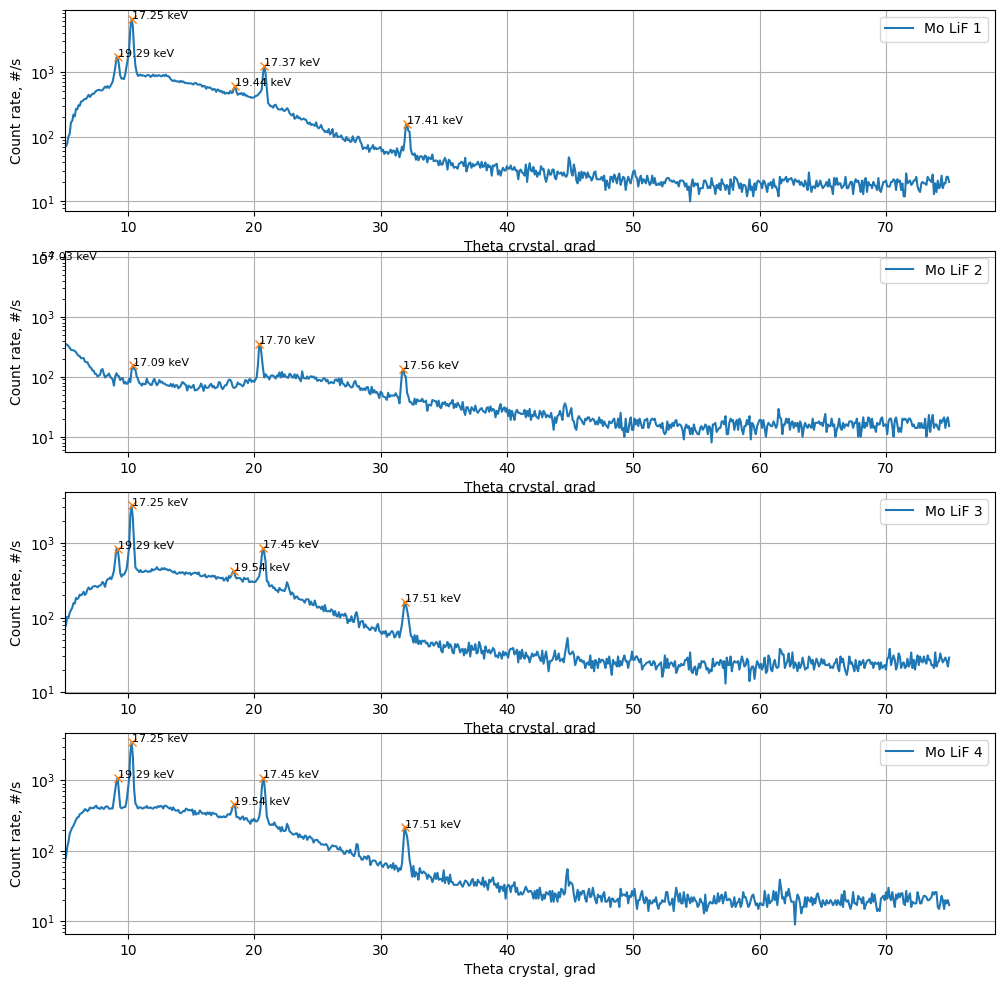

In [38]:
lamp = 'Mo'
crystal = 'LiF'
d = 201e-12 #m

fig, axs = plt.subplots(4, 1, figsize=(12, 12))
for n in  [1,2,3,4]:
  ax = axs[n-1]
  filename = URL + f'{lamp}_{crystal}_{n}.txt'
  theta, count = np.genfromtxt(filename, skip_header=3, unpack=True, encoding='latin1')
  theta_rad = theta * np.pi / 180
  peaks, _ = find_peaks(count, prominence=80)
  ax.plot(theta, count,  label=f'{lamp} {crystal} {n}')
  ax.plot(theta[peaks], count[peaks], 'x')

  l = 2 * d * np.sin(k_edge * np.pi / 180)
  E = h * c / l

  ax.set_yscale('log')
  ax.set_xlabel('Theta crystal, grad')
  ax.set_ylabel('Count rate, #/s')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(left=5)
  for peak in peaks:
    if theta[peak] < 15:
      order = 1
    elif theta[peak] < 30:
      order = 2
    else:
      order = 3
    l = 2 * d * np.sin(theta_rad[peak]) / order
    E = h * c / l
    #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
    ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)

  # photo of calibration
  #ax = axs[n-1,1]
  #filename = URL + f'{lamp}_{crystal}_{n}.jpg'
  #response = requests.get(filename, headers={"User-Agent": "Mozilla/5.0"})
  #image = Image.open(BytesIO(response.content))
  #ax.imshow(image)
  #ax.axis("off")  # Hides grid lines and pixel axes


# Fe + LiF

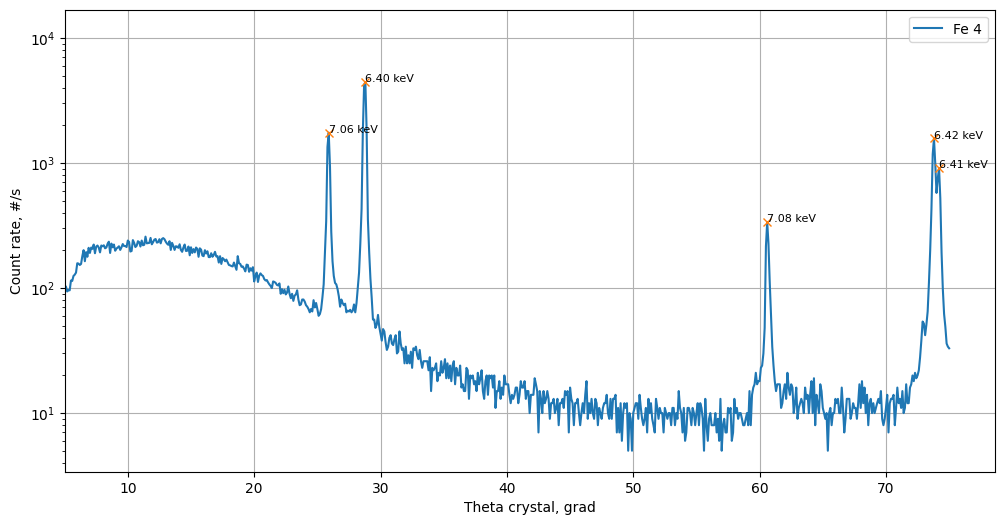

In [39]:
crystal = 'LiF'
lamp = 'Fe'
n = 4
d = 201e-12 #m

fig, axs = plt.subplots(1, 1, figsize=(12, 6))
ax = axs
filename = URL + f'{lamp}_{crystal}_{n}.txt'
theta, count = np.genfromtxt(filename, skip_header=3, unpack=True, encoding='latin1')
theta_rad = theta * np.pi / 180
peaks, _ = find_peaks(count, prominence=200)
ax.plot(theta, count,  label=f'{lamp} {n}')
ax.plot(theta[peaks], count[peaks], 'x')

l = 2 * d * np.sin(k_edge * np.pi / 180)
E = h * c / l

ax.set_yscale('log')
ax.set_xlabel('Theta crystal, grad')
ax.set_ylabel('Count rate, #/s')
ax.grid(True)
ax.legend()
ax.set_xlim(left=5)
for peak in peaks:
  if theta[peak] < 40:
    order = 1
  elif theta[peak] < 100:
    order = 2
  else:
    order = 3
  l = 2 * d * np.sin(theta_rad[peak]) / order
  E = h * c / l
  #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
  ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)



# Cu + LiF  

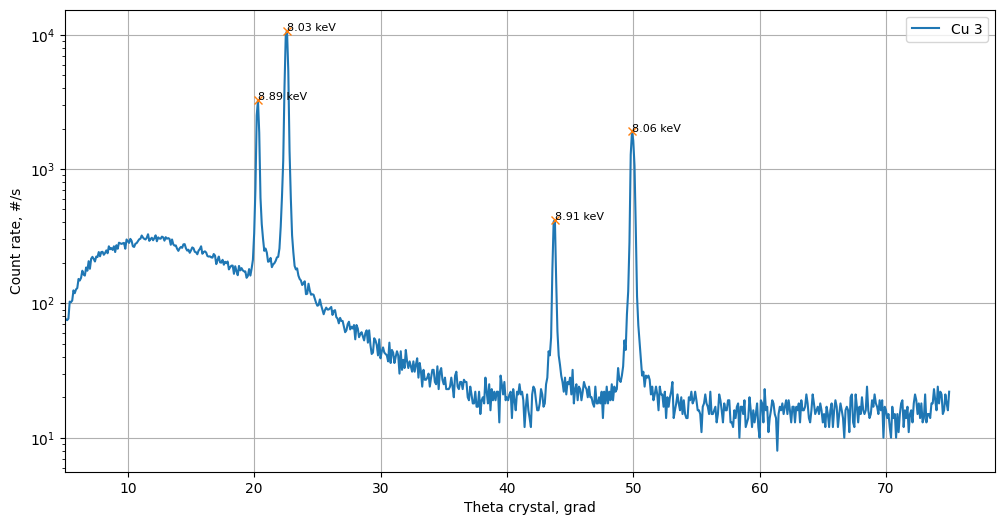

In [40]:
crystal = 'LiF'
lamp = 'Cu'
n = 3
d = 201e-12 #m

fig, axs = plt.subplots(1, 1, figsize=(12, 6))
ax = axs
filename = URL + f'{lamp}_{crystal}_{n}.txt'
theta, count = np.genfromtxt(filename, skip_header=3, unpack=True, encoding='latin1')
theta_rad = theta * np.pi / 180
peaks, _ = find_peaks(count, prominence=200)
ax.plot(theta, count,  label=f'{lamp} {n}')
ax.plot(theta[peaks], count[peaks], 'x')

l = 2 * d * np.sin(k_edge * np.pi / 180)
E = h * c / l

ax.set_yscale('log')
ax.set_xlabel('Theta crystal, grad')
ax.set_ylabel('Count rate, #/s')
ax.grid(True)
ax.legend()
ax.set_xlim(left=5)
for peak in peaks:
  if theta[peak] < 40:
    order = 1
  elif theta[peak] < 100:
    order = 2
  else:
    order = 3
  l = 2 * d * np.sin(theta_rad[peak]) / order
  E = h * c / l
  #print(f'{n}: Angle {theta[peak]:.2f} deg at order {order}, wavelength {l*1e10:.3f} Å, Energy {E/eV /1e3:.3f} keV')
  ax.text(theta[peak], count[peak], f'{E/eV /1e3:.2f} keV', fontsize=8)

